# Include

In [ ]:
!pip install geopandas
!pip install basemap
!pip install counter
!pip install igraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 860.7/860.7 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 26.7 MB/s eta 0:00:00


  Preparing metadata (setup.py) ... done
  Created wheel for counter: filename=Counter-1.0.0-py3-none-any.whl size=5394 sha256=467e8b341815b0064bb269a9ac2208cad77d09237a5b11bdc340912c29093a49
  Stored in directory: /root/.cache/pip/wheels/e3/02/6d/d5c0838427a060718c6060ae4d24da95a0e0df0d7a3dab8040
Successfully built counter
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 28.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import os
import re
import folium
import json
import sys
from folium.plugins import HeatMap
from tqdm.notebook import tqdm
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn import metrics
import geopandas
from collections import Counter
import geopy.distance
import igraph as ig

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Functions and Global Variables

In [ ]:
path = geopandas.datasets.get_path('nybb')
ny = geopandas.read_file(path)
ny = ny.to_crs(epsg=4326)
tk = geopandas.read_file("/content/drive/My Drive/data/gadm36_JPN.gpkg")
tk = tk[tk['NAME_1'] == 'Tokyo']
tk = tk.reset_index(drop=True)
t = [0,3,4,5,7,8,20,21,22,27,28,31,32,33,36,37,38,42,43,44,45,46,47,48,50,52]

<ipython-input-4-a078f3a91ff7>:1: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'nybb' data from the geodatasets package.

from geodatasets import get_path
path_to_file = get_path('nybb')

  path = geopandas.datasets.get_path('nybb')


In [ ]:
def find_all_indexes(lst, value):
    indexes = []
    for index, item in enumerate(lst):
        if item == value:
            indexes.append(index)
    return indexes

# Open DF

In [ ]:
df = pd.read_csv("/content/drive/My Drive/data/data1.csv", sep=";")
df.shape

(1020095, 9)

In [ ]:
df.head()

,fsq_id,swm_id,name,categorie,country,city,timestamp,latitude,longitude
0,4cc043410cc4b713ad3cedf7,1.382012e+09,梅田出入口,Toll Booth,JP,Osaka,2022-05-19 21:44:12.415195+09:00,34.700761,135.491450
1,57d4a224cd10ffc104e9b8c2,7.424768e+07,炉端肉焼き処猛伸 たけし,BBQ Joint,JP,Fukuoka,2022-05-19 21:44:14.307749+09:00,33.595423,130.411645
2,6136525917ce7a2afe7f16bc,5.019683e+06,The Blind Rabbit,Bar,GB,Nottingham,2022-05-19 13:44:18.364958+01:00,52.951511,-1.145812
3,4bbbd0392d9ea593dff39fce,1.350529e+08,北山田交差点,Public Transportation,JP,Yokohama,2022-05-19 21:44:35.349549+09:00,35.562375,139.588050
4,4d779ee18963f04d21e9ee37,9.268453e+07,Migros Ataköy Konakları - Ataköy Plus Avm,Department Store,TR,Bakırköy,2022-05-19 15:44:40.513704+03:00,40.978529,28.850354


## Define data type and drop rows with error

In [ ]:
df["latitude"] = pd.to_numeric(df["latitude"], errors='coerce') # typecast string para numerico
df["longitude"] = pd.to_numeric(df["longitude"], errors='coerce') # typecast string para numerico
df['swm_id'] = df['swm_id'].astype(str)
df = df[df["name"].str.contains("0") == False] # selecionando todas as linhas que não possuem "0" em name
df = df[df['latitude'] != 0.0]
df = df.dropna(axis=0, how='any') # drop do index antigo
df = df.reset_index() # resetando o index
del df['index'] # deletando coluna index
df['venue_weight'] = df['fsq_id'].map(df['fsq_id'].value_counts()) # add column weight
df["categorie"] = df["categorie"].apply(lambda x: x.replace("\\/", "/"))
df.head()

,fsq_id,swm_id,name,categorie,country,city,timestamp,latitude,longitude,venue_weight
0,4cc043410cc4b713ad3cedf7,1382011868.0,梅田出入口,Toll Booth,JP,Osaka,2022-05-19 21:44:12.415195+09:00,34.700761,135.491450,17
1,57d4a224cd10ffc104e9b8c2,74247679.0,炉端肉焼き処猛伸 たけし,BBQ Joint,JP,Fukuoka,2022-05-19 21:44:14.307749+09:00,33.595423,130.411645,2
2,6136525917ce7a2afe7f16bc,5019683.0,The Blind Rabbit,Bar,GB,Nottingham,2022-05-19 13:44:18.364958+01:00,52.951511,-1.145812,2
3,4bbbd0392d9ea593dff39fce,135052880.0,北山田交差点,Public Transportation,JP,Yokohama,2022-05-19 21:44:35.349549+09:00,35.562375,139.588050,2
4,4d779ee18963f04d21e9ee37,92684528.0,Migros Ataköy Konakları - Ataköy Plus Avm,Department Store,TR,Bakırköy,2022-05-19 15:44:40.513704+03:00,40.978529,28.850354,6


In [ ]:
#Counter(list(df["swm_id"].values)) # 79467187.0 -> 36721660.0
#df['venue_weight'][df['categorie'] == 'Bar'].sum()
#df['city'].value_counts()["Tokyo"]
#df[df["city"]=="Tokyo"].shape
#df["categorie"]
#df.shape

In [ ]:
venues = df.drop_duplicates(subset='fsq_id', inplace=False, keep='first')

# Categories

### Abrindo arquivo categorias

In [ ]:
# https://github.com/Factual/places/blob/master/categories/integrated_places_files/foursquare_to_integrated.json
# https://github.com/Factual/places/blob/master/categories/integrated_places_files/factual_to_integrated.json

with open('/content/drive/My Drive/data/new_cat.json') as json_file:
    data1 = json.load(json_file)

## Create dictionary to get full label from the categories

In [ ]:
dining = []; dining_cat = []; macro = []; category = []

for i in tqdm(data1, total=len(data1)):
    try:
      fsq_label = data1[str(i)]['foursquare_label'].split('>')
      macro.append(fsq_label[0].strip())
      category.append(fsq_label[len(fsq_label)-1].strip())
      splitted = data1[str(i)]['single_match']['integrated_category_label'].split('>')
      if splitted[0].strip() == "Dining and Drinking":
        dining.append(splitted[1].strip())
        dining_cat.append(splitted[len(splitted)-1].strip())
      macro.append(splitted[0].strip())
      category.append(splitted[len(splitted)-1].strip())
    except:
      splitted = data1[str(i)]['single_match']['integrated_category_label'].split('>')
      macro.append(splitted[0].strip())
      category.append(splitted[len(splitted)-1].strip())

my_dict = dict(zip(category,macro))
dining_dict = dict(zip(dining_cat,dining))

  0%|          | 0/1452 [00:00<?, ?it/s]

In [ ]:
my_dict['Golf Store'] = 'Retail'

my_dict['Hair Salon'] = 'Business and Professional Services'
my_dict['Barbershop'] = 'Business and Professional Services'
my_dict['Photographer'] = 'Business and Professional Services'

my_dict['University Tunku Abdul Rahman'] = 'Community and Government'
my_dict['Research Laboratory'] = 'Community and Government'

my_dict['Surf Store'] = 'Sports and Recreation'
my_dict['Soccer Club'] = 'Sports and Recreation'
my_dict['American Family Fitness- Corporate'] = 'Sports and Recreation'
my_dict['Soccer Match'] = 'Sports and Recreation'
my_dict['Martial Arts School'] = 'Sports and Recreation'

my_dict['Airport Ticket Counter'] = 'Travel and Transportation'

my_dict['Stables'] = 'Landmarks and Outdoors'

my_dict['Movie'] = 'Arts & Entertainment'
my_dict['Concert'] = 'Arts & Entertainment'

my_dict['Healthcare Clinic'] = 'Health and Medicine'
my_dict['Pathology Branch Of US CDC'] = 'Health and Medicine'
my_dict['Irwin Animal Hospital'] = 'Health and Medicine'

dining_dict['Dining and Drinking'] = 'Restaurant'
dining_dict['Salad Place'] = 'Restaurant'
dining_dict['Pizza Place'] = 'Restaurant'
dining_dict['Deli / Bodega'] = 'Restaurant'
dining_dict['Poke Place'] = 'Restaurant'
dining_dict['Noodle House'] = 'Restaurant'
dining_dict['Taco Place'] = 'Restaurant'
dining_dict['Burrito Place'] = 'Restaurant'
dining_dict['Sandwich Place'] = 'Restaurant'
dining_dict['Vegetarian / Vegan Restaurant'] = 'Restaurant'
dining_dict['Soup Place'] = 'Restaurant'

dining_dict['Irish Pub'] = 'Bar'
dining_dict['Nightclub'] = 'Bar'
dining_dict['Other Nightlife'] = 'Bar'

dining_dict['Ice Cream Shop'] = 'Dessert Shop'

In [ ]:
atoa = []
dif = []

for i in tqdm(df['categorie'], total=len(df)):
    try:
        atoa.append(my_dict[i])
    except:
        dif.append(i)

  0%|          | 0/985861 [00:00<?, ?it/s]

## Categories equivalence
 - Arts and Entertainment -> 0
 - Business and Professional Services -> 1
 - Community and Government -> 2
 - Dining and Drinking -> 3
 - Event -> 4
 - Health and Medicine -> 5
 - Landmarks and Outdoors -> 6
 - Retail -> 7
 - Sports and Recreation -> 8
 - Travel and Transportation -> 9
 - Residence -> 10

In [ ]:
macro_venues = []

for i in tqdm(df['categorie'], total=len(df)):
  try:
    #macro_venues.append(my_dict[i].strip())
    if my_dict[i] == 'Arts and Entertainment' or my_dict[i] == 'Arts & Entertainment': macro_venues.append(0)
    elif my_dict[i] == 'Business and Professional Services' or my_dict[i] == 'Professional & Other Places': macro_venues.append(1)
    elif my_dict[i] == 'Community and Government' or my_dict[i] == 'College & University': macro_venues.append(2)
    elif my_dict[i] == 'Dining and Drinking' or my_dict[i] == 'Nightlife Spot' or my_dict[i] == 'Food': macro_venues.append(3)
    elif my_dict[i] == 'Event': macro_venues.append(4)
    elif my_dict[i] == 'Health and Medicine': macro_venues.append(5)
    elif my_dict[i] == 'Landmarks and Outdoors' or my_dict[i] == 'Outdoors & Recreation': macro_venues.append(6)
    elif my_dict[i] == 'Retail' or my_dict[i] == 'Shop & Service': macro_venues.append(7)
    elif my_dict[i] == 'Sports and Recreation': macro_venues.append(8)
    elif my_dict[i] == 'Travel and Transportation' or my_dict[i] == 'Travel & Transport': macro_venues.append(9)
    elif my_dict[i] == 'Residence': macro_venues.append(10)
  except:
    macro_venues.append(np.nan)

'''venues['classification'] = macro_venues
venues = venues.dropna()
venues.reset_index(drop=True)'''

df['classification'] = macro_venues
df = df.dropna()
df.reset_index(drop=True)

  0%|          | 0/985861 [00:00<?, ?it/s]

,fsq_id,swm_id,name,categorie,country,city,timestamp,latitude,longitude,venue_weight,classification
0,4cc043410cc4b713ad3cedf7,1382011868.0,梅田出入口,Toll Booth,JP,Osaka,2022-05-19 21:44:12.415195+09:00,34.700761,135.491450,17,9.0
1,57d4a224cd10ffc104e9b8c2,74247679.0,炉端肉焼き処猛伸 たけし,BBQ Joint,JP,Fukuoka,2022-05-19 21:44:14.307749+09:00,33.595423,130.411645,2,3.0
2,6136525917ce7a2afe7f16bc,5019683.0,The Blind Rabbit,Bar,GB,Nottingham,2022-05-19 13:44:18.364958+01:00,52.951511,-1.145812,2,3.0
3,4bbbd0392d9ea593dff39fce,135052880.0,北山田交差点,Public Transportation,JP,Yokohama,2022-05-19 21:44:35.349549+09:00,35.562375,139.588050,2,9.0
4,4d779ee18963f04d21e9ee37,92684528.0,Migros Ataköy Konakları - Ataköy Plus Avm,Department Store,TR,Bakırköy,2022-05-19 15:44:40.513704+03:00,40.978529,28.850354,6,7.0
...,...,...,...,...,...,...,...,...,...,...,...
985124,514e6029e4b06c69f31c9ab0,167006340.0,相模原愛川IC,Toll Booth,JP,相模原市,2022-07-26 11:43:44.123777+09:00,35.527041,139.360504,41,9.0
985125,55bf0dc9498e7127c03f6ba7,1373827739.0,Chiba University Faculty of Engineering,College Engineering Building,JP,千葉市,2022-07-26 11:43:45.110315+09:00,35.626230,140.103289,6,2.0
985126,4cbac1ae4352a1cd5bef94f5,43452682.0,中華そば 寅 柄沢店,Ramen Restaurant,JP,藤沢市,2022-07-26 11:43:48.268534+09:00,35.348949,139.495443,5,3.0
985127,4c106a7c3ce120a1c624081c,55549627.0,CoCo壱番屋 鶴岡道形店,Japanese Curry Restaurant,JP,鶴岡市,2022-07-26 11:43:50.102373+09:00,38.743788,139.842677,4,3.0


### Create dict to get classification name by number

In [ ]:
labels = ['Arts and Entertainment','Business and Professional Services','Community and Government','Dining and Drinking','Event','Health and Medicine','Landmarks and Outdoors','Retail','Sports and Recreation','Travel and Transportation','Residence']
indexes = [0,1,2,3,4,5,6,7,8,9,10]

classification = dict(zip(indexes,labels))

## Defining timestamp

In [ ]:
### Create dict with dates and weekdays ###
dates = []; weekdays = []; time = []
for i in tqdm(list(df['timestamp'].values), total=len(df)):
  dates.append(i.split(' ')[0])
  if pd.Timestamp(i.split(' ')[0]).dayofweek < 5: weekdays.append(1)
  else: weekdays.append(0)
  aux = i.split(' ')[1].split('.')[0] #time.append(i.split(' ')[0])
  if   aux >= '00:00:00' and aux <= '05:59:59': time.append(0)
  elif aux >= '06:00:00' and aux <= '11:59:59': time.append(1)
  elif aux >= '12:00:00' and aux <= '17:59:59': time.append(2)
  elif aux >= '18:00:00' and aux <= '23:59:59': time.append(3)

dates = list(Counter(dates).keys())

weekday = []
for i in tqdm(dates, total=len(dates)):
  if pd.Timestamp(i).dayofweek < 5: weekday.append(1)
  else: weekday.append(0)

date = dict(zip(dates,weekday))

df['weekday'] = weekdays
df['time'] = time

  0%|          | 0/985129 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

# Scatter plot

### Defining city to be analysed (New York or Tokyo)

In [ ]:
# city = 'Tokyo'

# venues_city_complete = df
# venues_city_complete = venues_city_complete[venues_city_complete['city'] == city].sort_values(by=['timestamp'])
# if city == 'Tokyo': venues_city_complete = venues_city_complete[venues_city_complete['latitude'] > 10]
# venues_city = venues_city_complete.drop_duplicates(subset='fsq_id', inplace=False, keep='first')
# venues_city_complete.shape

In [ ]:
#df = df.drop([1916, 7410])

# city = 'Tokyo'
city = 'New York'
venues_city = df.drop_duplicates(subset='fsq_id', inplace=False, keep='first')
venues_city = venues_city[venues_city['city'] == city].sort_values(by=['timestamp'])
if city == 'Tokyo': venues_city = venues_city[venues_city['latitude'] > 10]
venues_city.shape

(1001, 13)

### Choosing the swm_id whitch has the greater number of check-ins

In [ ]:
x = Counter(list(venues_city["swm_id"].values)) # 79467187.0 -> 36721660.0
maior_id = [(l,k) for k,l in sorted([(j,i) for i,j in x.items()], reverse=True)][0][0]

user1 = venues_city[venues_city['swm_id'] == maior_id]
Counter(list(user1["city"].values))

Counter({'New York': 115})

###Split timestamp information, append to a list and then append to dataframe
Select the date with the biggest number of check-ins registred

In [ ]:
date = []
for i in tqdm(list(user1['timestamp'].values), total=len(user1)):
  date.append(i.split(' ')[0])
user1.insert(user1.shape[1], 'date', date)

  0%|          | 0/115 [00:00<?, ?it/s]

In [ ]:
d =Counter(list(user1["date"].values))
data_freq = [(l,k) for k,l in sorted([(j,i) for i,j in d.items()], reverse=True)][0][0]

user1 = user1[user1['date'] == data_freq]

print(f'Número de Venues visitadas pelo usuário {maior_id} no dia {data_freq}: \t' + str(len(user1['fsq_id'].values)))

Número de Venues visitadas pelo usuário 121055497.0 no dia 2022-06-26: 	11


# Graph Modeling


---


## TO DO
<ul>
 <li>Criar lista ordenada por horário de venues que o usuário visitou <strong>DONE</strong></li>
 <li>Fazer a lista de adjacência das 1001 venues <strong>DONE</strong></li>
 <li>Desenhar o grafo <strong>DONE</strong></li>
 <li>Fazer análises dos grafos obtidos</li>
</ul>

In [ ]:
paths = [] # Venues that each user visited

for user in tqdm(np.unique(venues_city['swm_id']), total=len(np.unique(venues_city['swm_id']))):
  paths.append(list(venues_city['fsq_id'][venues_city['swm_id'] == user]))

  0%|          | 0/290 [00:00<?, ?it/s]

In [ ]:
# if venue exists in paths[i], append paths[i] to venue's adjacency list else continue
venues_unique = np.unique(list(venues_city['fsq_id']))
adjacency = []

for v in tqdm(venues_unique, total=len(venues_unique)):
  aux = []
  for p in paths:
    if v in p:
      aux = aux + [path[1] for path in enumerate(p) if v not in path]
  adjacency.append([v] + aux) # if not weighted graph, call adjacency.unique()

  0%|          | 0/1001 [00:00<?, ?it/s]

Defining edges

In [ ]:
lat_dict = dict(zip(list(venues['fsq_id']), list(venues['latitude'])))
lon_dict = dict(zip(list(venues['fsq_id']), list(venues['longitude'])))

In [ ]:
# Edge: (adjacency[i][0], adjacency[i][j], count, distance)
edges = []

for i in tqdm(range(0, len(adjacency)), total=len(adjacency)):
  coords_1 = (lat_dict[adjacency[i][0]], lon_dict[adjacency[i][0]])
  counter = Counter(adjacency[i])
  for j in range(1, len(adjacency[i])):
    aux = []
    coords_2 = (lat_dict[adjacency[i][j]], lon_dict[adjacency[i][j]])
    dist =  round(geopy.distance.geodesic(coords_1, coords_2).km, 2)
    edges.append([adjacency[i][0], adjacency[i][j], lat_dict[adjacency[i][0]], lon_dict[adjacency[i][0]], lat_dict[adjacency[i][j]], lon_dict[adjacency[i][j]], str(counter[adjacency[i][j]]), str(dist)])

  0%|          | 0/1001 [00:00<?, ?it/s]

In [ ]:
edges = pd.DataFrame(edges, columns=['start', 'end', 'lat_start', 'lon_start', 'lat_end', 'lon_end', 'count', 'distance']).drop_duplicates() # can coordinates be a tuple?

In [ ]:
g = ig.Graph.TupleList(edges.itertuples(index=False), directed=False)

In [ ]:
edges.itertuples(index=False)

In [ ]:
layout = g.layout(layout='auto')

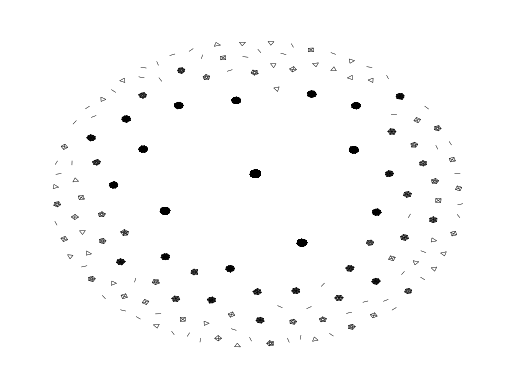

In [ ]:
# ig.config['plotting.backend'] = 'matplotlib'

fig1, ax1 = plt.subplots()
ig.plot(
    g,
    target=ax1,
    mark_groups=True,
    vertex_color='red',
    vertex_size=.2,
    edge_width=.2,
    edge_color='black',
)
#fig1.set_size_inches(20, 20)

#plt.savefig("grafo.png", transparent=True)

In [ ]:
test = g.components()
len(test.subgraphs())

152

In [ ]:
sum = 0
for i in range(78):
  sum += test.subgraphs()[i].vcount()
  #print(test.subgraphs()[i].vcount())

In [ ]:
big = []
for v in test.subgraphs()[0].vs:
    big.append(v['name'])

#if id in big...

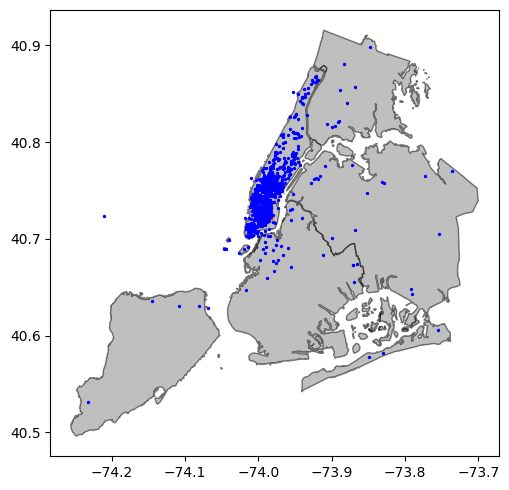

In [ ]:
selected = venues_city[venues_city['fsq_id'].isin(big)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
not_selected = venues_city[~venues_city['fsq_id'].isin(big)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')

tk.iloc[t,:].plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black') if city == 'Tokyo' else ny.plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black')
scatter = plt.scatter(selected['longitude'], selected['latitude'], c='#ff0000', s=2, alpha=1)
scatter2 = plt.scatter(not_selected['longitude'], not_selected['latitude'], c='#0000ff', s=2, alpha=1)

plt.savefig("componente.png", transparent=True)
plt.tight_layout()
plt.show()

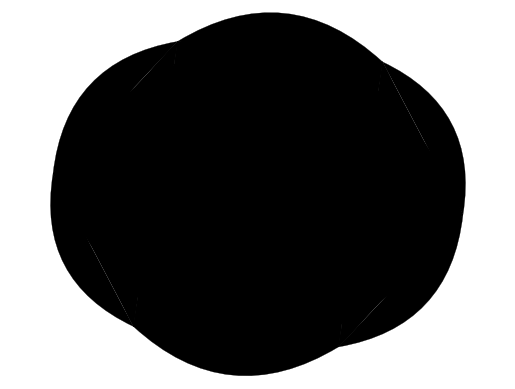

In [ ]:
fig1, ax1 = plt.subplots()
ig.plot(
    test.subgraphs()[0],
    target=ax1,
    mark_groups=True,
    vertex_color='red',
    vertex_size=.2,
    edge_width=.2,
    edge_color='black',
)
#fig1.set_size_inches(20, 20)

# Graph Clustering


In [ ]:
teste = []
venues_city = venues_city.drop_duplicates(subset='fsq_id', inplace=False, keep='first').reset_index(drop=True)
for i, j in tqdm(zip(venues_city['latitude'], venues_city['longitude']), total=len(venues_city)):
  teste.append([i, j])

  0%|          | 0/1001 [00:00<?, ?it/s]

In [ ]:
from sklearn.neighbors import KDTree
tree = KDTree(teste, leaf_size=2, metric='euclidean')
if city == 'Tokyo': dist, ind = tree.query(teste, k=11)
else: dist, ind = tree.query(teste, k=6)

In [ ]:
# Edge: (adjacency[i][0], adjacency[i][j], count, distance)
edges = []

for i in tqdm(range(0, len(adjacency)), total=len(adjacency)):
  coords_1 = (lat_dict[adjacency[i][0]], lon_dict[adjacency[i][0]])
  counter = Counter(adjacency[i])
  for j in range(1, len(adjacency[i])):
    aux = []
    coords_2 = (lat_dict[adjacency[i][j]], lon_dict[adjacency[i][j]])
    dist =  round(geopy.distance.geodesic(coords_1, coords_2).km, 2)
    edges.append([adjacency[i][0], adjacency[i][j], lat_dict[adjacency[i][0]], lon_dict[adjacency[i][0]], lat_dict[adjacency[i][j]], lon_dict[adjacency[i][j]], str(counter[adjacency[i][j]]), str(dist)])

  0%|          | 0/1001 [00:00<?, ?it/s]

In [ ]:
grafo = []

for i in tqdm(range(len(ind)), total=len(ind)):
  coord_b = (venues_city.iloc[ind[i][0]].latitude, venues_city.iloc[ind[i][0]].longitude)
  #print(venues_city.iloc[i])
  for j in range(1, len(ind[i])):
    coord_e = (venues_city.iloc[ind[i][j]].latitude, venues_city.iloc[ind[i][j]].longitude)
    dist =  round(geopy.distance.geodesic(coord_b, coord_e).km, 2)
    grafo.append([venues_city.iloc[ind[i][0]].fsq_id, venues_city.iloc[ind[i][j]].fsq_id, dist])

  0%|          | 0/1001 [00:00<?, ?it/s]

In [ ]:
grafo = pd.DataFrame(grafo, columns=['start', 'end', 'distance']).drop_duplicates() # can coordinates be a tuple?
grafo['sorted_nodes'] = grafo.apply(lambda row: tuple(sorted([row['start'], row['end']])), axis=1)
grafo = grafo.drop_duplicates(subset='sorted_nodes').drop(columns='sorted_nodes').reset_index(drop=True)
#grafo = pd.DataFrame(grafo, columns=['start', 'end', 'coord_start', 'coord_end', 'distance']).drop_duplicates() # can coordinates be a tuple?

In [ ]:
g2 = ig.Graph.TupleList(grafo.itertuples(index=False), directed=False, edge_attrs={'weight': grafo.distance})
grafo.itertuples(index=False)
layout = g2.layout(layout='auto')

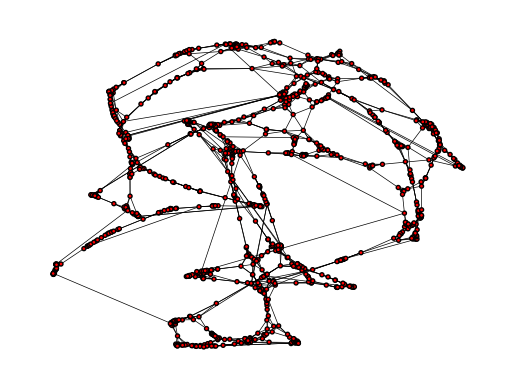

In [ ]:
# ig.config['plotting.backend'] = 'matplotlib'

fig1, ax1 = plt.subplots()
ig.plot(
    g2,
    target=ax1,
    mark_groups=True,
    vertex_color='red',
    vertex_size=4,
    edge_width=.5,
    edge_color='black',
)
#fig1.set_size_inches(20, 20)

#plt.savefig("grafo.png", transparent=True)

In [ ]:
g2_components = g2.components()
g2_max_degree = g2.maxdegree()
print(f'components: {len(g2_components.subgraphs())}\nmax degree: {g2_max_degree}')

components: 1
max degree: 11


In [ ]:
big = []
for v in g2_components.subgraphs()[0].vs:
    big.append(v['name'])

#if id in big...

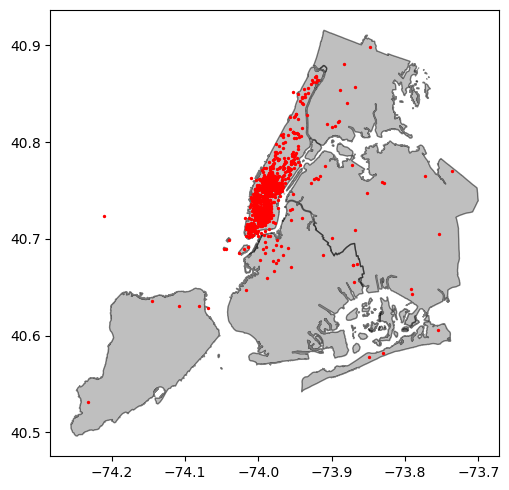

In [ ]:
selected = venues_city[venues_city['fsq_id'].isin(big)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
not_selected = venues_city[~venues_city['fsq_id'].isin(big)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')

tk.iloc[t,:].plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black') if city == 'Tokyo' else ny.plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black')
scatter = plt.scatter(selected['longitude'], selected['latitude'], c='#ff0000', s=2, alpha=1)
scatter2 = plt.scatter(not_selected['longitude'], not_selected['latitude'], c='#0000ff', s=2, alpha=1)

plt.savefig("componente.png", transparent=True)
plt.tight_layout()
plt.show()

## Generate MST

In [ ]:
mst = g2.spanning_tree(weights=g2.es["weight"], return_tree=True)

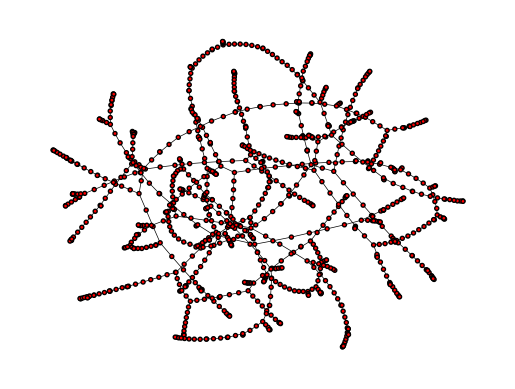

In [ ]:
fig1, ax1 = plt.subplots()
ig.plot(
    mst,
    target=ax1,
    mark_groups=True,
    vertex_color='red',
    vertex_size=4,
    edge_width=.5,
    edge_color='black',
)
#fig1.set_size_inches(20, 20)

#plt.savefig("grafo.png", transparent=True)

In [ ]:
g3_components = mst.components()
g3_max_degree = mst.maxdegree()
print(f'components: {len(g3_components.subgraphs())}\nmax degree: {g3_max_degree}')

components: 1
max degree: 4


## Felzenszwalb Segmentation

Export graph to .txt file

In [ ]:
f = open('graph.txt', 'w')
f.write(f'{len(mst.vs)} {len(mst.es)}\n')
for i in tqdm(mst.vs, total = len(mst.vs)):
  f.write(i['name'] + '\n')
for i in tqdm(mst.es, total = len(mst.es)):
  w = i['weight']
  source = mst.vs[i.source]['name']
  target = mst.vs[i.target]['name']
  f.write(f'{source} {target} {w}\n')

  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Import graph from .txt file

In [ ]:
vertex = []
edge = []
remove = []

f = open('/content/drive/My Drive/data/input1.txt', 'r')
n_vertex, n_edges = f.readline().strip().split(' ')

for i in tqdm(range(int(n_vertex)), total = int(n_vertex)):
  vertex.append(f.readline().strip())
for i in tqdm(range(int(n_edges)), total = int(n_edges)):
  edge.append(f.readline().strip().split(' '))

n_remove = f.readline().strip()
for i in tqdm(range(int(n_remove)), total = int(n_remove)):
  source, target = f.readline().strip().split(' ')
  remove.append(source)
  remove.append(target)

index = []

for i in mst.vs:
  for j in remove:
    if i['name'] == j:
      index.append(i.index)

pairs = [(remove[i], remove[i + 1]) for i in range(0, len(remove), 2)]

  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Create graph from .txt file

In [ ]:
new_g = pd.DataFrame(edge, columns=['source', 'target', 'weight'])
alt_g = ig.Graph.TupleList(new_g.itertuples(index=False), directed=False, edge_attrs={'weight': new_g.weight})
new_g.itertuples(index=False)
layout = alt_g.layout(layout='auto')
for i in pairs:
  alt_g.delete_edges(i)

alt_g_components = alt_g.components()
alt_g_max_degree = alt_g.maxdegree()
print(f'components: {len(alt_g_components.subgraphs())}\nmax degree: {alt_g_max_degree}')

components: 2
max degree: 4


In [ ]:
f = open('c2.txt', 'w')
f.write(f'{len(alt_g.components().subgraphs()[1].vs)} {len(alt_g.components().subgraphs()[1].es)}\n')
for i in tqdm(alt_g.components().subgraphs()[1].vs, total = len(alt_g.components().subgraphs()[1].vs)):
  f.write(i['name'] + '\n')
for i in tqdm(alt_g.components().subgraphs()[1].es, total = len(alt_g.components().subgraphs()[1].es)):
  w = i['weight']
  source = alt_g.components().subgraphs()[1].vs[i.source]['name']
  target = alt_g.components().subgraphs()[1].vs[i.target]['name']
  f.write(f'{source} {target} {w}\n')

  0%|          | 0/521 [00:00<?, ?it/s]

  0%|          | 0/520 [00:00<?, ?it/s]

In [ ]:
alt_g.delete_edges(('40d38200f964a52041011fe3','5b491723de3bbf002ccb56d8'))
alt_g.delete_edges(('4c278081a852c928be4fe86c','3fd66200f964a520ede61ee3'))

In [ ]:
alt_g_components = alt_g.components()
alt_g_max_degree = alt_g.maxdegree()
print(f'components: {len(alt_g_components.subgraphs())}\nmax degree: {alt_g_max_degree}')

components: 4
max degree: 4


In [ ]:
sum = 0
for i in range(len(alt_g.components().subgraphs())):
  sum += len(alt_g.components().subgraphs()[i].vs)
  print(f'Component {i}\t{len(alt_g.components().subgraphs()[i].vs)} vertex')
print(sum)

Component 0	393 vertex
Component 1	438 vertex
Component 2	83 vertex
Component 3	87 vertex
1001


Venues ID of each component on graph

In [ ]:
big0 = []
for v in alt_g_components.subgraphs()[0].vs:
    big0.append(v['name'])

big1 = []
for v in alt_g_components.subgraphs()[1].vs:
    big1.append(v['name'])

big2 = []
for v in alt_g_components.subgraphs()[2].vs:
    big2.append(v['name'])

big3 = []
for v in alt_g_components.subgraphs()[3].vs:
    big3.append(v['name'])

Graph plot

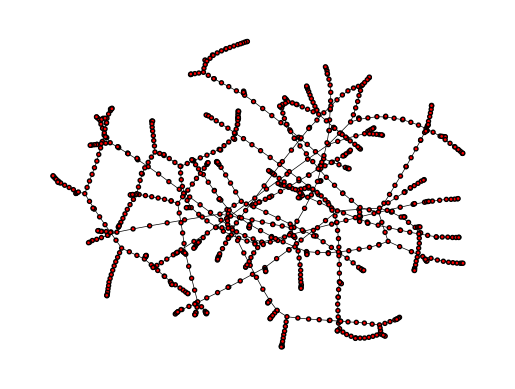

In [ ]:
fig1, ax1 = plt.subplots()
ig.plot(
    alt_g,
    target=ax1,
    mark_groups=True,
    vertex_color='red',
    vertex_size=4,
    edge_width=.5,
    edge_color='black',
)
#fig1.set_size_inches(20, 20)

#plt.savefig("grafo.png", transparent=True)

Scatter plot with clusters

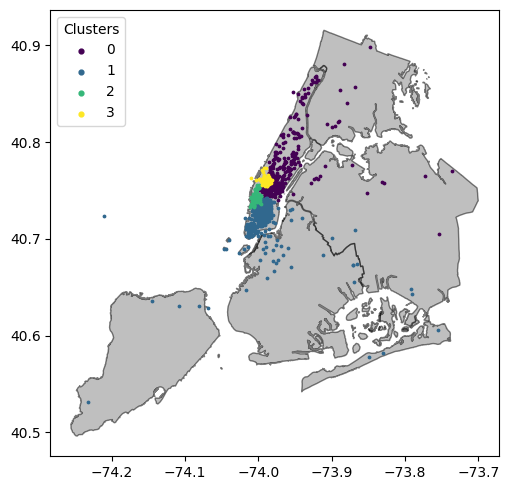

In [ ]:
g0 = venues_city[venues_city['fsq_id'].isin(big0)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
g1 = venues_city[venues_city['fsq_id'].isin(big1)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
g2 = venues_city[venues_city['fsq_id'].isin(big2)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
g3 = venues_city[venues_city['fsq_id'].isin(big3)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
color = ['#440154', '#31688e', '#35b779', '#fde725']

tk.iloc[t,:].plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black') if city == 'Tokyo' else ny.plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black')
scatter  = plt.scatter(g0['longitude'], g0['latitude'], c=color[0], s=3, alpha=1, label='0')
scatter2 = plt.scatter(g1['longitude'], g1['latitude'], c=color[1], s=3, alpha=1, label='1')
scatter3 = plt.scatter(g2['longitude'], g2['latitude'], c=color[2], s=3, alpha=1, label='2')
scatter4 = plt.scatter(g3['longitude'], g3['latitude'], c=color[3], s=3, alpha=1, label='3')
# ax.legend(title='Cluster')

plt.legend(title='Clusters', loc="upper left", markerscale=2)
plt.savefig("teste1000.png", dpi=1000)
plt.tight_layout()
plt.show()

## HIGRA

In [ ]:
# !pip install higra

In [ ]:
# import higra as hg

# foo = dict(zip(list(mst.vs), list(range(0, len(mst.vs)))))

# weight = []

# gh = hg.UndirectedGraph(len(mst.vs))

# for i in tqdm(mst.es, total = len(mst.es)):
#   weight.append(i['weight'])
#   gh.add_edge(i.source, i.target)

In [ ]:
# tree, altitude = hg.watershed_hierarchy_by_area(gh, weight)

In [ ]:
# # a = hg.attribute_dynamics(tree, altitude)
# # a = hg.attribute_depth(tree)
# a = hg.attribute_area(tree)

# extinction = hg.attribute_extinction_value(tree, altitude, a)

In [ ]:
# foo = hg.labelisation_horizontal_cut_from_num_regions(extinction, altitude, 4, mode='at_most', leaf_graph=None)

In [ ]:
# input = np.ones((tree.num_leaves(),))

# result = hg.accumulate_sequential(tree, input, hg.Accumulators.sum)

In [ ]:
# len(result)

In [ ]:
# sm = hg.graph_4_adjacency_2_khalimsky(gh, hg.saliency(tree, altitude))**0.5
# sm = sm[1::2,1::2]
# sm = np.pad(sm, ((0,1),(0,1)), mode='edge')
# sm = 1 - sm / np.max(sm)
# sm = np.dstack([sm]*3)
# #alpha channel
# sm = np.pad(sm, ((0,0),(0,0),(0,1)), mode='constant', constant_values=1)


In [ ]:
# tree_attribute = hg.attribute_vertex_area(gh)
# extintion = hg.attribute_extinction_value(tree, altitude, tree_attribute, increasing_altitudes='auto')

In [ ]:
# num_components = 4
# components = hg.cut_tree_watershed_by_area(gh, num_components)

# # Visualizar as componentes
# for i in range(num_components):
#     component_vertices = np.where(components == i)[0]
#     print(f"Component {i}: Vertices {component_vertices}")

## Remove edges
Statically dividing the MST into 4 clusters.

In [ ]:
# to_delete = 0
# best = sys.maxsize
# #g_cut = mst.copy()
# g_cut = mst.copy()
# ordered_weigth = []
# j = 0

# #for i in tqdm(range(len(g_cut.subgraphs())), total=len(g_cut.subgraphs())): # THIS LOOP MUST CONTROL HOW MANY CLUSTERS I WANT
# for i in g_cut.es: # iterate through all edges in g_cut.components().subgraphs()[0]
#   n_components = len(g_cut.components().subgraphs()) + 1
#   weight = i['weight']
#   g_cut.delete_edges([i.index]) # delete edge with weight = ordered_weight[j]
#   diff = abs(len(g_cut.components().subgraphs()[0].vs) - len(g_cut.components().subgraphs()[1].vs))
#   #print(f'1: {len(g_cut.components().subgraphs()[0].vs)} \t 2: {len(g_cut.components().subgraphs()[1].vs)} \t diff: {diff}\t weight: {weight} \t index: {i.index}')
#   if len(g_cut.components().subgraphs()) == n_components and diff < 10:
#     to_delete = i.index
#     best = diff
#   #g_cut = mst.copy()
#   g_cut = mst.copy()
#   j += 1

# g_cut.delete_edges([to_delete])

In [ ]:
def remove_edges(g):
  g_aux = g.copy()
  to_delete = 0
  best = sys.maxsize
  for i in g_aux.es: # iterate through all edges in g_aux
    n_components = len(g_aux.components().subgraphs()) + 1
    g_aux.delete_edges([i.index])
    diff = abs(len(g_aux.components().subgraphs()[0].vs) - len(g_aux.components().subgraphs()[1].vs))
    if len(g_aux.components().subgraphs()) == n_components and diff < best:
      to_delete = i.index
      best = diff
    g_aux = g.copy()

  g.delete_edges([to_delete])
  return g

g_cut0: mst divided into 2 connected components
<br><br>
g_cut1: first connected component from g_cut0 divided into 2 more components <br>
g_cut2: second connected component from g_cut0 divided into 2 more components
<br><br>
g_cut: union between g_cut1 and g_cut2, obtaining a graph with 4 connected components

Árvore de fusões

Higra

In [ ]:
g_cut0 = remove_edges(mst.copy())

g_cut1 = remove_edges(g_cut0.components().subgraphs()[0].copy())
g_cut2 = remove_edges(g_cut0.components().subgraphs()[1].copy())

# g_cut3 = remove_edges(g_cut1.components().subgraphs()[0].copy()) Segmentação Baseada em área
# g_cut4 = remove_edges(g_cut1.components().subgraphs()[1].copy()) Árvore de Fusões

# g_cut5 = remove_edges(g_cut2.components().subgraphs()[0].copy())
# g_cut6 = remove_edges(g_cut2.components().subgraphs()[1].copy())

g_cut = ig.union([g_cut1, g_cut2])
# g_cut = ig.union([g_cut3, g_cut4, g_cut5, g_cut6])

In [ ]:
g_cut_components = g_cut.components()
g_cut_max_degree = g_cut.maxdegree()
print(f'components: {len(g_cut_components.subgraphs())}\nmax degree: {g_cut_max_degree}')

components: 4
max degree: 4


In [ ]:
sum = 0
for i in range(len(g_cut.components().subgraphs())):
  sum += len(g_cut.components().subgraphs()[i].vs)
  print(f'Component {i}\t{len(g_cut.components().subgraphs()[i].vs)} vertex')
print(sum)

Component 0	237 vertex
Component 1	261 vertex
Component 2	226 vertex
Component 3	277 vertex
1001


In [ ]:
len(mst.vs)

1001

In [ ]:
big0 = []
for v in g_cut_components.subgraphs()[0].vs:
    big0.append(v['name'])

big1 = []
for v in g_cut_components.subgraphs()[1].vs:
    big1.append(v['name'])

big2 = []
for v in g_cut_components.subgraphs()[2].vs:
    big2.append(v['name'])

big3 = []
for v in g_cut_components.subgraphs()[3].vs:
    big3.append(v['name'])

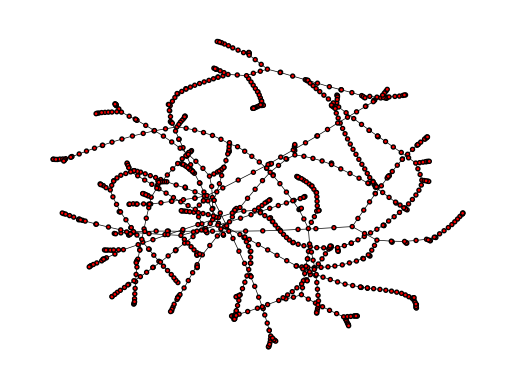

In [ ]:
fig1, ax1 = plt.subplots()
ig.plot(
    g_cut,
    target=ax1,
    mark_groups=True,
    vertex_color='red',
    vertex_size=4,
    edge_width=.5,
    edge_color='black',
)
#fig1.set_size_inches(20, 20)

#plt.savefig("grafo.png", transparent=True)

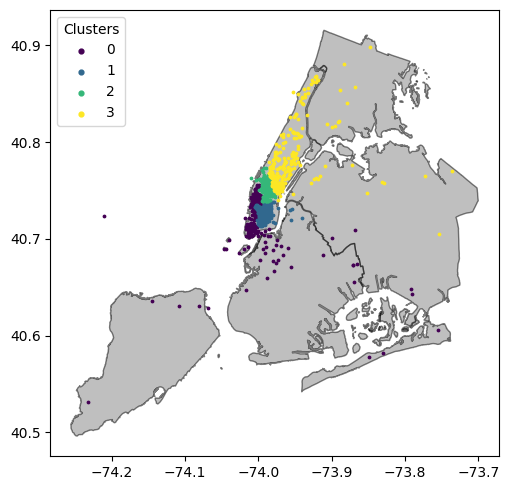

In [ ]:
g0 = venues_city[venues_city['fsq_id'].isin(big0)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
g1 = venues_city[venues_city['fsq_id'].isin(big1)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
g2 = venues_city[venues_city['fsq_id'].isin(big2)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
g3 = venues_city[venues_city['fsq_id'].isin(big3)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
color = ['#440154', '#31688e', '#35b779', '#fde725']

tk.iloc[t,:].plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black') if city == 'Tokyo' else ny.plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black')
scatter  = plt.scatter(g0['longitude'], g0['latitude'], c=color[0], s=3, alpha=1, label='0')
scatter2 = plt.scatter(g1['longitude'], g1['latitude'], c=color[1], s=3, alpha=1, label='1')
scatter3 = plt.scatter(g2['longitude'], g2['latitude'], c=color[2], s=3, alpha=1, label='2')
scatter4 = plt.scatter(g3['longitude'], g3['latitude'], c=color[3], s=3, alpha=1, label='3')
# ax.legend(title='Cluster')

plt.legend(title='Clusters', loc="upper left", markerscale=2)
plt.savefig("teste1000.png", dpi=1000)
plt.tight_layout()
plt.show()

## Remove the k most relevant edges

In [ ]:
import math
g_k_edges = mst.copy()

ordered_weight_k = g_k_edges.components().subgraphs()[0].es['weight']
ordered_weight_k = list(set(ordered_weight_k))
ordered_weight_k.sort(reverse=True)

k = 40
idx = []

for i in ordered_weight_k[:k]:
  ind = find_all_indexes(g_k_edges.components().subgraphs()[0].es['weight'], i)
  for j in ind: idx.append(j)

g_k_edges.delete_edges(idx[:k])

In [ ]:
g_k_edges_components = g_k_edges.components()
g_k_edges_max_degree = g_k_edges.maxdegree()
print(f'components: {len(g_k_edges_components.subgraphs())}\nmax degree: {g_k_edges_max_degree}')

components: 41
max degree: 4


In [ ]:
for i in range(len(g_k_edges.components().subgraphs())):
  print(f'Component {i}\t{len(g_k_edges.components().subgraphs()[i].vs)} vertex')

Component 0	921 vertex
Component 1	22 vertex
Component 2	1 vertex
Component 3	5 vertex
Component 4	1 vertex
Component 5	3 vertex
Component 6	1 vertex
Component 7	1 vertex
Component 8	1 vertex
Component 9	1 vertex
Component 10	1 vertex
Component 11	1 vertex
Component 12	2 vertex
Component 13	1 vertex
Component 14	6 vertex
Component 15	1 vertex
Component 16	1 vertex
Component 17	1 vertex
Component 18	1 vertex
Component 19	2 vertex
Component 20	1 vertex
Component 21	5 vertex
Component 22	1 vertex
Component 23	1 vertex
Component 24	2 vertex
Component 25	1 vertex
Component 26	1 vertex
Component 27	1 vertex
Component 28	1 vertex
Component 29	1 vertex
Component 30	1 vertex
Component 31	1 vertex
Component 32	1 vertex
Component 33	1 vertex
Component 34	2 vertex
Component 35	1 vertex
Component 36	1 vertex
Component 37	1 vertex
Component 38	1 vertex
Component 39	1 vertex
Component 40	1 vertex


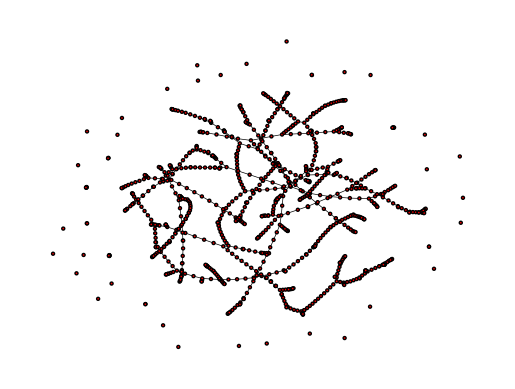

In [ ]:
fig1, ax1 = plt.subplots()
ig.plot(
    g_k_edges,
    target=ax1,
    mark_groups=True,
    vertex_color='red',
    vertex_size=3,
    edge_width=.5,
    edge_color='black',
)
#fig1.set_size_inches(20, 20)

#plt.savefig("grafo.png", transparent=True)

In [ ]:
cc_g_k_0 = []
for v in g_k_edges_components.subgraphs()[0].vs:
    cc_g_k_0.append(v['name'])

cc_g_k_1 = []
for v in g_k_edges_components.subgraphs()[1].vs:
    cc_g_k_1.append(v['name'])

# cc_g_k_2 = []
# for v in g_k_edges_components.subgraphs()[8].vs:
#     cc_g_k_2.append(v['name'])

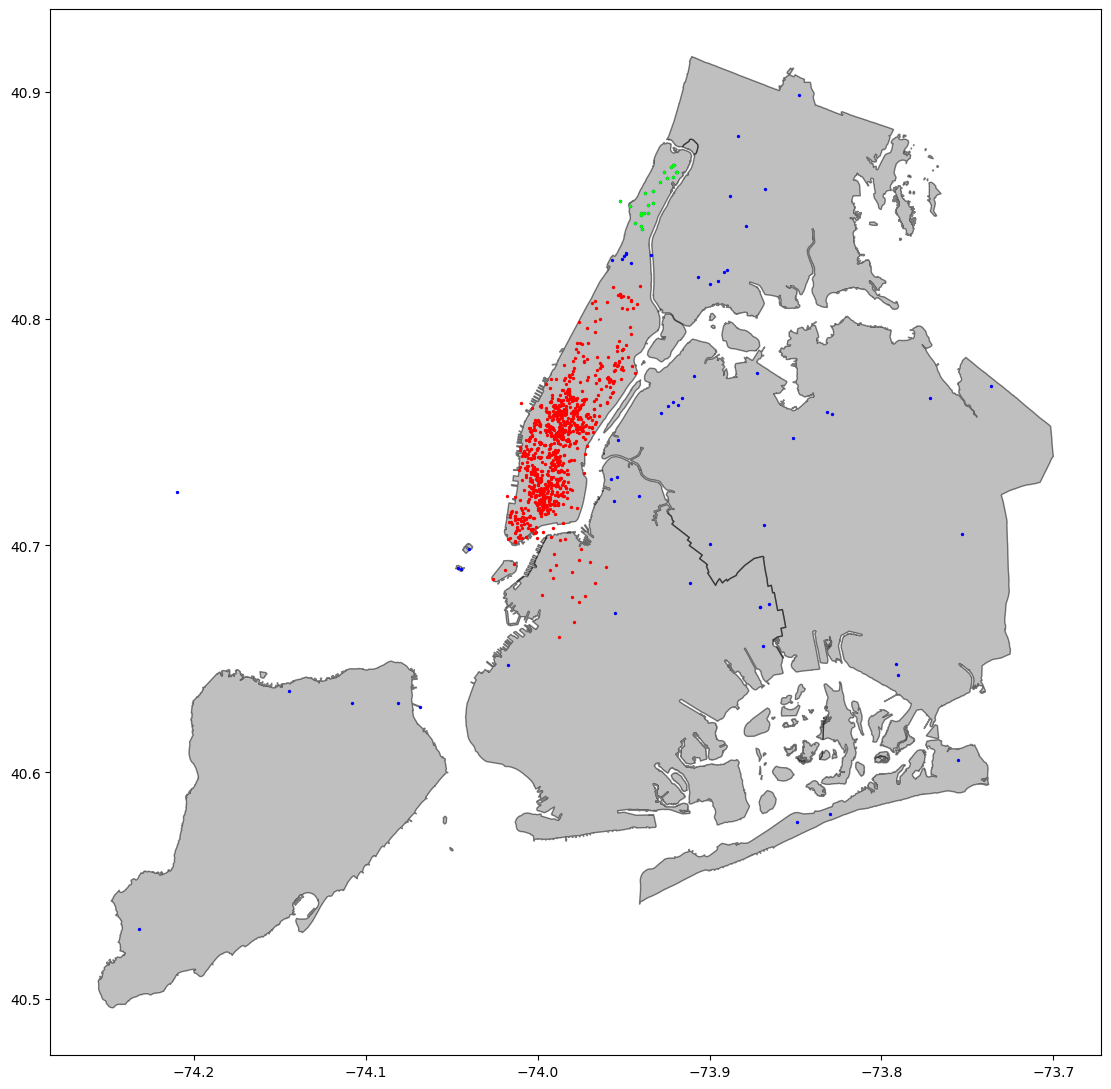

In [ ]:
g0 = venues_city[venues_city['fsq_id'].isin(cc_g_k_0)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
g1 = venues_city[~venues_city['fsq_id'].isin(cc_g_k_0)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
g2 = venues_city[venues_city['fsq_id'].isin(cc_g_k_1)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
# g3 = venues_city[~venues_city['fsq_id'].isin(cc_g_k_2) & ~venues_city['fsq_id'].isin(cc_g_k_1) & ~venues_city['fsq_id'].isin(cc_g_k_0)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')

tk.iloc[t,:].plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black') if city == 'Tokyo' else ny.plot(figsize=(12,11), color='gray', alpha=0.5, edgecolor='black')
scatter = plt.scatter(g0['longitude'], g0['latitude'], c='#ff0000', s=2, alpha=1)
scatter2 = plt.scatter(g1['longitude'], g1['latitude'], c='#0000ff', s=2, alpha=1)
scatter3 = plt.scatter(g2['longitude'], g2['latitude'], c='#00ff00', s=2, alpha=1)
# scatter4 = plt.scatter(g3['longitude'], g3['latitude'], c='#000000', s=2, alpha=1)

plt.savefig("componente.png", transparent=True)
plt.tight_layout()
plt.show()

## Search for the edge that divides the graph into 2 connected components with the most similar number of vertices

<ul>
  <li> The edges are ordered by its weight
  <li> Need to find a Threshold to define witch is the best edge to cut, relating the weight from the edge and the number of vertices in each CC

In [ ]:
to_delete = 0
best = sys.maxsize
math = sys.maxsize
g_aux = mst.copy()
ordered_weight = g_aux.components().subgraphs()[0].es['weight']
ordered_weight = list(set(ordered_weight)) # Remove duplicated weight
ordered_weight.sort(reverse=True) # Order weight list in non-decrescent order

for i in ordered_weight:
  n_components = len(g_aux.components().subgraphs()) + 1
  ind = find_all_indexes(g_aux.components().subgraphs()[0].es['weight'], i)
  for j in ind:
    g_aux.delete_edges([j])
    diff = abs(len(g_aux.components().subgraphs()[0].vs) - len(g_aux.components().subgraphs()[1].vs))
    try:
      aux = round((diff)*(1/i), 2)
    except:
      aux = round((diff)*(1/1), 2)
    if len(g_aux.components().subgraphs()) == n_components and aux < math and diff < best:
      print(f'1: {len(g_aux.components().subgraphs()[0].vs)} \t 2: {len(g_aux.components().subgraphs()[1].vs)} \t diff: {diff}\t weight: {i} \t index: {j} \t math: {aux}')
      to_delete = j
      best = diff
      math = aux
    g_aux = mst.copy()

g_aux.delete_edges([to_delete])

1: 1000 	 2: 1 	 diff: 999	 weight: 13.81 	 index: 726 	 math: 72.34
1: 495 	 2: 506 	 diff: 11	 weight: 0.16 	 index: 17 	 math: 68.75
1: 504 	 2: 497 	 diff: 7	 weight: 0.16 	 index: 656 	 math: 43.75


In [ ]:
g_aux_components = g_aux.components()
g_aux_max_degree = g_aux.maxdegree()
print(f'components: {len(g_aux_components.subgraphs())}\nmax degree: {g_aux_max_degree}')

components: 2
max degree: 4


In [ ]:
for i in range(len(g_aux.components().subgraphs())):
  print(f'Component {i}\t{len(g_aux.components().subgraphs()[i].vs)} vertex')

Component 0	504 vertex
Component 1	497 vertex


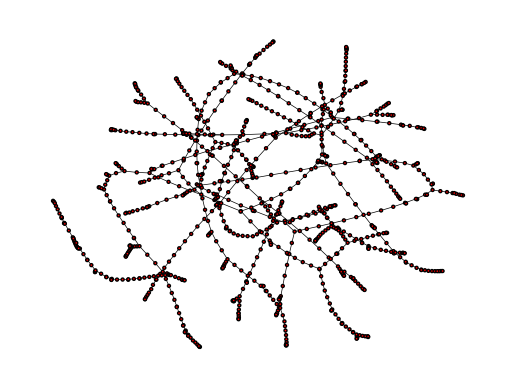

In [ ]:
fig1, ax1 = plt.subplots()
ig.plot(
    g_aux,
    target=ax1,
    mark_groups=True,
    vertex_color='red',
    vertex_size=3,
    edge_width=.5,
    edge_color='black',
)
#fig1.set_size_inches(20, 20)

#plt.savefig("grafo.png", transparent=True)

In [ ]:
big0 = []
for v in g_aux_components.subgraphs()[0].vs:
    big0.append(v['name'])

big1 = []
for v in g_aux_components.subgraphs()[1].vs:
    big1.append(v['name'])

# big2 = []
# for v in g_aux_components.subgraphs()[8].vs:
#     big2.append(v['name'])

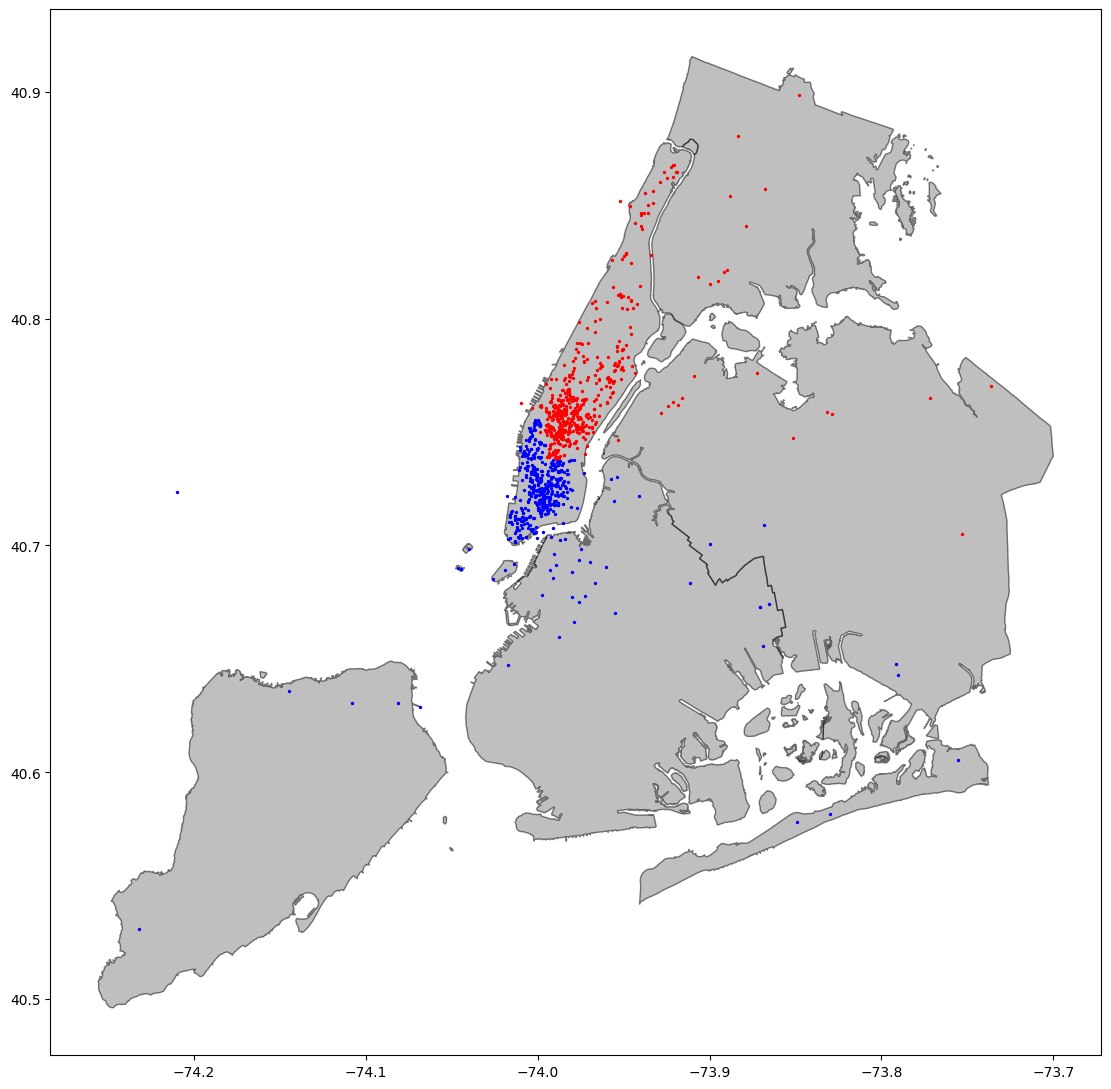

In [ ]:
g0 = venues_city[venues_city['fsq_id'].isin(big0)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
g1 = venues_city[venues_city['fsq_id'].isin(big1)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
# g2 = venues_city[venues_city['fsq_id'].isin(big2)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')
# g3 = venues_city[~venues_city['fsq_id'].isin(big2) & ~venues_city['fsq_id'].isin(big1) & ~venues_city['fsq_id'].isin(big0)].drop_duplicates(subset='fsq_id', inplace=False, keep='first')

tk.iloc[t,:].plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black') if city == 'Tokyo' else ny.plot(figsize=(12,11), color='gray', alpha=0.5, edgecolor='black')
scatter = plt.scatter(g0['longitude'], g0['latitude'], c='#ff0000', s=2, alpha=1)
scatter2 = plt.scatter(g1['longitude'], g1['latitude'], c='#0000ff', s=2, alpha=1)
# scatter3 = plt.scatter(g2['longitude'], g2['latitude'], c='#00ff00', s=2, alpha=1)
# scatter4 = plt.scatter(g3['longitude'], g3['latitude'], c='#000000', s=2, alpha=1)

plt.savefig("componente.png", transparent=True)
plt.tight_layout()
plt.show()

# Analyse generated clusters

In [ ]:
cc0 = []
for v in g_cut.components().subgraphs()[0].vs:
    cc0.append(v['name'])

cc1 = []
for v in g_cut.components().subgraphs()[1].vs:
    cc1.append(v['name'])

cc2 = []
for v in g_cut.components().subgraphs()[2].vs:
    cc2.append(v['name'])

cc3 = []
for v in g_cut.components().subgraphs()[3].vs:
    cc3.append(v['name'])

In [ ]:
cluster = []

for i in venues_city['fsq_id']:
  if i in cc0:
    cluster.append(0)
  elif i in cc1:
    cluster.append(1)
  elif i in cc2:
    cluster.append(2)
  elif i in cc3:
    cluster.append(3)

venues_city['cluster'] = cluster

## No time filter

In [ ]:
my_dict = dict(zip(list(venues_city['fsq_id']), list(venues_city['cluster'])))

In [ ]:
city_df = df
city_df = city_df[city_df['city'] == city].sort_values(by=['timestamp'])
cluster_values = []

for i in tqdm(city_df['fsq_id'], total=city_df.shape[0]):
  cluster_values.append(my_dict[i])

city_df['cluster'] = cluster_values

  0%|          | 0/1916 [00:00<?, ?it/s]

In [ ]:
cp_venues = df
cp_venues['cluster'] = city_df['cluster']

cp_venues = cp_venues.dropna()
cp_venues.reset_index(drop=True)
cp_venues.shape

(1916, 14)

In [ ]:
for i in range(4):
  #print(f'CLUSTER {i}')
  maximum = []
  for j in range(0,10):
    x = cp_venues[cp_venues['cluster'] == i]
    maximum.append(x[x['classification'] == j].shape[0])
    #print(f'{classification[j]} -> ' + str(maximum[j]))
  print(f'Cluster {i} -> {classification[maximum.index(max(maximum))]}\t{x.shape}')

Cluster 0 -> Dining and Drinking	(412, 14)
Cluster 1 -> Dining and Drinking	(452, 14)
Cluster 2 -> Dining and Drinking	(488, 14)
Cluster 3 -> Dining and Drinking	(564, 14)


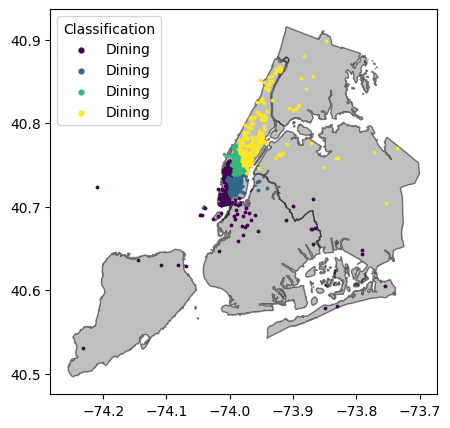

In [ ]:
Entrada = venues_city.iloc[:, [7,8,13]].values
cluster = np.array(cluster)

tk.iloc[t,:].plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black') if city == 'Tokyo' else ny.plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black')

classifica = ['Dining', 'Dining', 'Dining', 'Dining']
color = ['#440154', '#31688e', '#35b779', '#fde725']
for i in range(0,4):
  plt.scatter(Entrada[cluster == i, 1], Entrada[cluster == i, 0], s = 3, c = color[i], label = classifica[i])
#Plotting the centroids of the clusters
# plt.legend(title='Classification', loc="upper left", markerscale=3)
# title.set_weight("bold")

if city == 'Tokyo': legend = plt.legend(loc="lower right", markerscale=2)
else: legend = plt.legend(loc="upper left", markerscale=2)

legend.set_title("Classification")
title = legend.get_title()
# title.set_weight("bold")

In [ ]:
### DINING AND DRINKING ###
count = []
for i in range(4):
  x = cp_venues[cp_venues['cluster'] == i]
  x = x[x['classification'] == 3.0]
  for k in x['categorie']: count.append(dining_dict[k])
  print(f'\ncluster {i}')
  print(pd.Series(count).value_counts())
  print('\n')


cluster 0
Restaurant                       91
Bar                              31
Cafes, Coffee, and Tea Houses    20
Smoothie Shop                     4
Food Truck                        3
Dessert Shop                      3
Breakfast Spot                    2
Bakery                            2
Food Court                        1
dtype: int64



cluster 1
Restaurant                       206
Bar                              109
Cafes, Coffee, and Tea Houses     56
Bakery                            14
Dessert Shop                      13
Smoothie Shop                      4
Food Court                         4
Food Truck                         3
Breakfast Spot                     2
Juice Bar                          2
Distillery                         1
dtype: int64



cluster 2
Restaurant                       283
Bar                              148
Cafes, Coffee, and Tea Houses     89
Bakery                            22
Dessert Shop                      17
Juice Bar            

## Temporal analysis

### Weekdays

In [ ]:
cp_venues = city_df
cp_venues['cluster'] = city_df['cluster']

cp_venues = cp_venues.dropna()
cp_venues.reset_index(drop=True)
cp_venues.shape

(1916, 14)

In [ ]:
for i in range(4):
  #print(f'\nCLUSTER {i} -> weekday')
  maximum = []
  for j in range(0,10):
    x = cp_venues[cp_venues['cluster'] == i]
    x = x[x['weekday'] == 1]
    maximum.append(x[x['classification'] == j].shape[0])
    #print(f'{classification[j]} -> ' + str(maximum[j]))
  print(f'Cluster ({i}) cluster weekday -> {classification[maximum.index(max(maximum))]}\t{x.shape}')

  #print(f'\nCLUSTER {i} -> weekend')
  maximum = []
  for j in range(0,10):
    x = cp_venues[cp_venues['cluster'] == i]
    x = x[x['weekday'] == 0]
    maximum.append(x[x['classification'] == j].shape[0])
    #print(f'{classification[j]} -> ' + str(maximum[j]))
  print(f'Cluster ({i}) cluster weekend -> {classification[maximum.index(max(maximum))]}\t{x.shape}\n\n')

Cluster (0) cluster weekday -> Dining and Drinking	(237, 14)
Cluster (0) cluster weekend -> Dining and Drinking	(175, 14)


Cluster (1) cluster weekday -> Dining and Drinking	(239, 14)
Cluster (1) cluster weekend -> Dining and Drinking	(213, 14)


Cluster (2) cluster weekday -> Dining and Drinking	(280, 14)
Cluster (2) cluster weekend -> Dining and Drinking	(208, 14)


Cluster (3) cluster weekday -> Landmarks and Outdoors	(342, 14)
Cluster (3) cluster weekend -> Dining and Drinking	(222, 14)




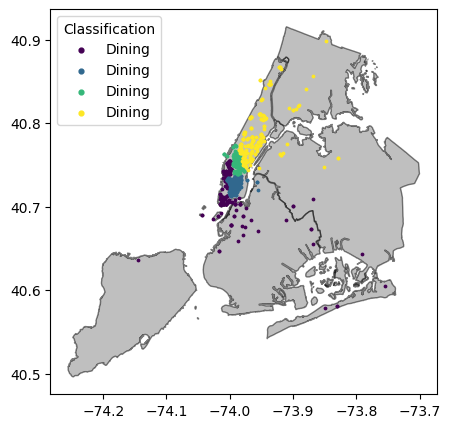

In [ ]:
Entrada = cp_venues[cp_venues['weekday'] == 0].iloc[:,[7,8,13]]
labels_city_time = cp_venues[cp_venues['weekday'] == 0].iloc[:,[7,8,13]]


tk.iloc[t,:].plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black') if city == 'Tokyo' else ny.plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black')

classifica = ['Dining', 'Dining', 'Dining', 'Dining']
color = ['#440154', '#31688e', '#35b779', '#fde725']
for i in range(0,4):
    #print(labels_city[i])
  plt.scatter(Entrada[labels_city_time['cluster'] == i].iloc[:,1], Entrada[labels_city_time['cluster'] == i].iloc[:,0], s = 3, c = color[i], label = classifica[i])
#Plotting the centroids of the clusters
if city == 'Tokyo': legend = plt.legend(loc="lower right", markerscale=2)
else: legend = plt.legend(loc="upper left", markerscale=2)

legend.set_title("Classification")
title = legend.get_title()

In [ ]:
# MONTAR GRÁFICOS PARA MELHORAR A VISUALIZAÇÃO DOS RESULTADOS
#np.unique(np.array(list(dining_dict.values())))

In [ ]:
### DINING AND DRINKING ###
for i in range(4):
  count = []
  x = cp_venues[cp_venues['cluster'] == i]
  x = x[x['weekday'] == 1]
  x = x[x['classification'] == 3.0]
  for k in x['categorie']:
    count.append(dining_dict[k])
  print(f'CLUSTER {i} -> weekday\t{x.shape}')
  if len(count) > 0: print(pd.Series(count).value_counts())
  else: print('There\'s no Dining and Drinking')
  print()

  count = []

  x = cp_venues[cp_venues['cluster'] == i]
  x = x[x['weekday'] == 0]
  x = x[x['classification'] == 3.0]
  for k in x['categorie']:
    count.append(dining_dict[k])
  print(f'CLUSTER {i} -> weekend\t{x.shape}')
  if len(count) > 0: print(pd.Series(count).value_counts())
  else: print('There\'s no Dining and Drinking')
  print()

CLUSTER 0 -> weekday	(81, 14)
Restaurant                       50
Cafes, Coffee, and Tea Houses    13
Bar                              11
Dessert Shop                      3
Breakfast Spot                    2
Food Truck                        1
Bakery                            1
dtype: int64

CLUSTER 0 -> weekend	(76, 14)
Restaurant                       41
Bar                              20
Cafes, Coffee, and Tea Houses     7
Smoothie Shop                     4
Food Truck                        2
Food Court                        1
Bakery                            1
dtype: int64

CLUSTER 1 -> weekday	(119, 14)
Restaurant                       57
Bar                              37
Cafes, Coffee, and Tea Houses    17
Bakery                            4
Dessert Shop                      2
Distillery                        1
Juice Bar                         1
dtype: int64

CLUSTER 1 -> weekend	(138, 14)
Restaurant                       58
Bar                              41
Cafes, C

### Time interval

In [ ]:
cp_venues = city_df
cp_venues['cluster'] = city_df['cluster']

cp_venues = cp_venues.dropna()
cp_venues.reset_index(drop=True)
cp_venues.shape

(1916, 14)

In [ ]:
for i in range(4):
  #print(f'\nCLUSTER {i} -> time: 0')
  maximum = []
  for j in range(0,10):
    x = cp_venues[cp_venues['cluster'] == i]
    x = x[x['time'] == 0]
    maximum.append(x[x['classification'] == j].shape[0])

    #print(f'{classification[j]} -> ' + str(maximum[j]))
  print(f'Cluster {i} cluster \t 00:00 until 05:59 \t {classification[maximum.index(max(maximum))]}\t{x.shape}')

  #print(f'\nCLUSTER {i} \t time: 1')
  maximum = []
  for j in range(0,10):
    x = cp_venues[cp_venues['cluster'] == i]
    x = x[x['time'] == 1]
    maximum.append(x[x['classification'] == j].shape[0])

    #print(f'{classification[j]} \t ' + str(maximum[j]))
  print(f'Cluster {i} cluster\t 06:00 until 11:59 \t {classification[maximum.index(max(maximum))]}\t{x.shape}')

  #print(f'\nCLUSTER {i} \t time: 2')
  maximum = []
  for j in range(0,10):
    x = cp_venues[cp_venues['cluster'] == i]
    x = x[x['time'] == 2]
    maximum.append(x[x['classification'] == j].shape[0])

  print(f'Cluster {i} cluster\t 12:00 until 17:59 \t {classification[maximum.index(max(maximum))]}\t{x.shape}')
    #print(f'{classification[j]} \t ' + str(maximum[j]))

  #print(f'\nCLUSTER {i} \t time: 3')
  maximum = []
  for j in range(0,10):
    x = cp_venues[cp_venues['cluster'] == i]
    x = x[x['time'] == 3]
    maximum.append(x[x['classification'] == j].shape[0])

    #print(f'{classification[j]} \t ' + str(maximum[j]))
  print(f'Cluster {i} cluster\t 18:00 until 23:59 \t {classification[maximum.index(max(maximum))]}\t{x.shape}\n\n')

Cluster 0 cluster 	 00:00 until 05:59 	 Arts and Entertainment	(14, 14)
Cluster 0 cluster	 06:00 until 11:59 	 Travel and Transportation	(86, 14)
Cluster 0 cluster	 12:00 until 17:59 	 Dining and Drinking	(183, 14)
Cluster 0 cluster	 18:00 until 23:59 	 Dining and Drinking	(129, 14)


Cluster 1 cluster 	 00:00 until 05:59 	 Dining and Drinking	(39, 14)
Cluster 1 cluster	 06:00 until 11:59 	 Dining and Drinking	(68, 14)
Cluster 1 cluster	 12:00 until 17:59 	 Dining and Drinking	(170, 14)
Cluster 1 cluster	 18:00 until 23:59 	 Dining and Drinking	(175, 14)


Cluster 2 cluster 	 00:00 until 05:59 	 Travel and Transportation	(34, 14)
Cluster 2 cluster	 06:00 until 11:59 	 Travel and Transportation	(110, 14)
Cluster 2 cluster	 12:00 until 17:59 	 Dining and Drinking	(177, 14)
Cluster 2 cluster	 18:00 until 23:59 	 Dining and Drinking	(167, 14)


Cluster 3 cluster 	 00:00 until 05:59 	 Landmarks and Outdoors	(37, 14)
Cluster 3 cluster	 06:00 until 11:59 	 Landmarks and Outdoors	(151, 14)
Clu

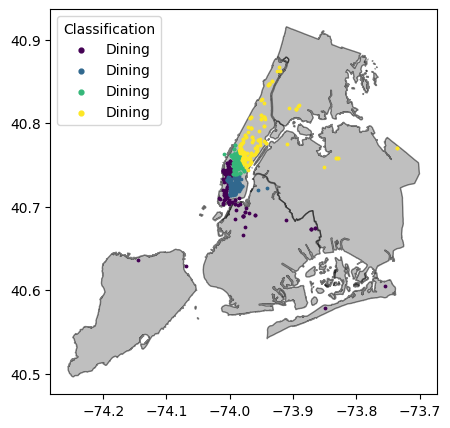

In [ ]:
#Entrada = cp_venues[(cp_venues['time'] == 2) | (cp_venues['time'] == 3)].iloc[:,[7,8,13]]
#labels_city_time = cp_venues[(cp_venues['time'] == 2) | (cp_venues['time'] == 3)].iloc[:,[7,8,13]]
Entrada = cp_venues[(cp_venues['time'] == 3)].iloc[:,[7,8,13]]
labels_city_time = cp_venues[(cp_venues['time'] == 3)].iloc[:,[7,8,13]]


tk.iloc[t,:].plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black') if city == 'Tokyo' else ny.plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black')

classifica = ['Dining', 'Dining', 'Dining', 'Dining']
color = ['#440154', '#31688e', '#35b779', '#fde725']
plt.scatter(Entrada[labels_city_time['cluster'] == 0].iloc[:,1], Entrada[labels_city_time['cluster'] == 0].iloc[:,0], s = 3, c = color[0], label = classifica[0])
plt.scatter(Entrada[labels_city_time['cluster'] == 1].iloc[:,1], Entrada[labels_city_time['cluster'] == 1].iloc[:,0], s = 3, c = color[1], label = classifica[1])
plt.scatter(Entrada[labels_city_time['cluster'] == 2].iloc[:,1], Entrada[labels_city_time['cluster'] == 2].iloc[:,0], s = 3, c = color[2], label = classifica[2])
plt.scatter(Entrada[labels_city_time['cluster'] == 3].iloc[:,1], Entrada[labels_city_time['cluster'] == 3].iloc[:,0], s = 3, c = color[3], label = classifica[3])
#Plotting the centroids of the clusters
if city == 'Tokyo': legend = plt.legend(loc="lower right", markerscale=2)
else: legend = plt.legend(loc="upper left", markerscale=2)

legend.set_title("Classification")
title = legend.get_title()

In [ ]:
### DINING AND DRINKING ###
for i in range(4):
  ### TIME 0
  count = []
  x = cp_venues[cp_venues['cluster'] == i]
  x = x[x['time'] == 0]
  x = x[x['classification'] == 3.0]
  for k in x['categorie']: count.append(dining_dict[k])
  print(f'CLUSTER {i} \t 00:00 until 05:59\t{x.shape}')
  if len(count) > 0: print(pd.Series(count).value_counts())
  else: print('There\'s no Dining and Drinking')
  print()

  ### TIME 1
  count = []
  x = cp_venues[cp_venues['cluster'] == i]
  x = x[x['time'] == 1]
  x = x[x['classification'] == 3.0]
  for k in x['categorie']: count.append(dining_dict[k])
  print(f'CLUSTER {i} \t 06:00 until 11:59\t{x.shape}')
  if len(count) > 0: print(pd.Series(count).value_counts())
  else: print('There\'s no Dining and Drinking')
  print()

  ### TIME 2
  count = []
  x = cp_venues[cp_venues['cluster'] == i]
  x = x[x['time'] == 2]
  x = x[x['classification'] == 3.0]
  for k in x['categorie']: count.append(dining_dict[k])
  print(f'CLUSTER {i} \t 12:00 until 17:59\t{x.shape}')
  if len(count) > 0: print(pd.Series(count).value_counts())
  else: print('There\'s no Dining and Drinking')
  print()

  ### TIME 3
  count = []
  x = cp_venues[cp_venues['cluster'] == i]
  x = x[x['time'] == 3]
  x = x[x['classification'] == 3.0]
  for k in x['categorie']: count.append(dining_dict[k])
  print(f'CLUSTER {i} \t 18:00 until 23:59\t{x.shape}')
  if len(count) > 0: print(pd.Series(count).value_counts())
  else: print('There\'s no Dining and Drinking')
  print()

CLUSTER 0 	 00:00 until 05:59	(2, 14)
Bar    2
dtype: int64

CLUSTER 0 	 06:00 until 11:59	(10, 14)
Smoothie Shop                    4
Cafes, Coffee, and Tea Houses    3
Bar                              1
Breakfast Spot                   1
Bakery                           1
dtype: int64

CLUSTER 0 	 12:00 until 17:59	(69, 14)
Restaurant                       43
Cafes, Coffee, and Tea Houses    14
Bar                               8
Food Court                        1
Dessert Shop                      1
Breakfast Spot                    1
Bakery                            1
dtype: int64

CLUSTER 0 	 18:00 until 23:59	(76, 14)
Restaurant                       48
Bar                              20
Food Truck                        3
Cafes, Coffee, and Tea Houses     3
Dessert Shop                      2
dtype: int64

CLUSTER 1 	 00:00 until 05:59	(30, 14)
Bar           23
Restaurant     7
dtype: int64

CLUSTER 1 	 06:00 until 11:59	(28, 14)
Restaurant                       13
Cafes, Coff

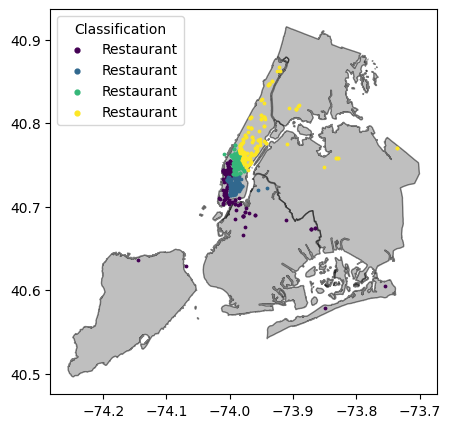

In [ ]:
#Entrada = cp_venues[(cp_venues['time'] == 2) | (cp_venues['time'] == 3)].iloc[:,[7,8,13]]
#labels_city_time = cp_venues[(cp_venues['time'] == 2) | (cp_venues['time'] == 3)].iloc[:,[7,8,13]]
Entrada = cp_venues[(cp_venues['time'] == 3)].iloc[:,[7,8,13]]
labels_city_time = cp_venues[(cp_venues['time'] == 3)].iloc[:,[7,8,13]]


tk.iloc[t,:].plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black') if city == 'Tokyo' else ny.plot(figsize=(6,5), color='gray', alpha=0.5, edgecolor='black')

classifica = ['Restaurant', 'Restaurant', 'Restaurant', 'Restaurant']
color = ['#440154', '#31688e', '#35b779', '#fde725']
for i in range(0,4):
    #print(labels_city[i])
  plt.scatter(Entrada[labels_city_time['cluster'] == i].iloc[:,1], Entrada[labels_city_time['cluster'] == i].iloc[:,0], s = 3, c = color[i], label = classifica[i])
#Plotting the centroids of the clusters
if city == 'Tokyo': legend = plt.legend(loc="lower right", markerscale=2)
else: legend = plt.legend(loc="upper left", markerscale=2)

legend.set_title("Classification")
title = legend.get_title()